# Setup

In [1]:
# Pandas and numpy are standard libraries for dataframes and scientific computing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# The scikit-learn module "tree" implements decision tree classification and related tools
from sklearn import tree

# test-train-split automates the division of a dataset into training data and validation data
from sklearn.model_selection import train_test_split

# cross-val-scrore will let us cross-validate decision trees to find the honest tree
from sklearn.model_selection import cross_val_score

# calculate accuracy score
from sklearn import metrics


## 1 Import and inspect the data

I used real data from the National Health Interview Survey on dietary habits. Specifically, I used individual information to predict respondents' preferred type of breakfast cereal. The IPUMS dataset is concerned with the relationship between diet and health, so you can think of this as a big-data exercise in trying to figure out who eats unhealthy, sugary cereals.

The data are taken from:
Lynn A. Blewett, Julia A. Rivera Drew, Miriam L. King, Kari C.W. Williams, Natalie Del Ponte and Pat Convey. IPUMS Health Surveys: National Health Interview Survey, Version 7.1 [dataset]. Minneapolis, MN: IPUMS, 2021.
doi.org/10.18128/D070.V7.1

The file `cereal_data.dta` was provided to me with the target variable, last cereal eaten by the respondent, already cleaned.

In [2]:
df=pd.read_stata(r"C:\Users\mattv\OneDrive\Documents\Academics\University of Southern California\04 - Fall 2022\03 - PPD 599 Special Topics (Python)\Problem Sets\cereal_data.dta")

In [3]:
df

,pernum,age,sex,sexorien,marstcohab,hispyn,educ,empstat,incfam07on,ownership,...,cerealmtyp1,hrsleep,sleepfall,vitmo,race_white,race_black,race_native,race_asian,race_other_multiple,cereal_num
0,1,25,Male,"Straight, that is, not lesbian or gay",Never married,"No, not of Hispanic ethnicity",AA degree: technical/vocational/occupational,Working for pay at job/business,"$0 - $34,999",Rented,...,Other,7 hours,Did not have trouble falling asleep past week,NIU,1.0,0.0,0.0,0.0,0.0,11.0
1,1,61,Male,"Straight, that is, not lesbian or gay",Never married,"No, not of Hispanic ethnicity","Bachelor's degree (BA,AB,BS,BBA)",Working for pay at job/business,"$50,000 - $74,999",Owned or being bought,...,Other,6 hours,Did not have trouble falling asleep past week,No,0.0,0.0,0.0,1.0,0.0,11.0
2,1,53,Male,"Straight, that is, not lesbian or gay",Divorced,"No, not of Hispanic ethnicity",AA degree: academic program,Working for pay at job/business,"$75,000 - $99,999",Rented,...,Oatmeal,4 hours,7 or more times,NIU,0.0,1.0,0.0,0.0,0.0,10.0
3,2,31,Female,"Straight, that is, not lesbian or gay","Married, spouse present","No, not of Hispanic ethnicity","Bachelor's degree (BA,AB,BS,BBA)",Working for pay at job/business,"$100,000 and over",Rented,...,Other,7 hours,Did not have trouble falling asleep past week,No,1.0,0.0,0.0,0.0,0.0,11.0
4,2,58,Female,"Straight, that is, not lesbian or gay","Married, spouse present","No, not of Hispanic ethnicity","Some college, no degree",Working for pay at job/business,"$35,000 - $49,999",Owned or being bought,...,Other,8 hours,Did not have trouble falling asleep past week,No,0.0,1.0,0.0,0.0,0.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18735,1,72,Male,"Straight, that is, not lesbian or gay","Married, spouse present","No, not of Hispanic ethnicity","Bachelor's degree (BA,AB,BS,BBA)",Not in labor force,"$100,000 and over",Owned or being bought,...,Oatmeal,7 hours,Did not have trouble falling asleep past week,No,1.0,0.0,0.0,0.0,0.0,10.0
18736,1,72,Male,"Straight, that is, not lesbian or gay","Married, spouse present","No, not of Hispanic ethnicity","Bachelor's degree (BA,AB,BS,BBA)",Working for pay at job/business,"$100,000 and over",Owned or being bought,...,Other,7 hours,1,NIU,1.0,0.0,0.0,0.0,0.0,11.0
18737,1,60,Female,"Straight, that is, not lesbian or gay","Married, spouse present","No, not of Hispanic ethnicity",Grade 11,Not in labor force,"$0 - $34,999",Rented,...,Corn flakes,4 hours,Did not have trouble falling asleep past week,No,0.0,1.0,0.0,0.0,0.0,3.0
18738,1,55,Male,"Straight, that is, not lesbian or gay",Divorced,"No, not of Hispanic ethnicity","Bachelor's degree (BA,AB,BS,BBA)",Working for pay at job/business,"$75,000 - $99,999",Owned or being bought,...,Frosted flakes,7 hours,2,No,1.0,0.0,0.0,0.0,0.0,4.0


In [4]:
#Tabulate value counts for cereal_num
df.cereal_num.value_counts()

cereal_num
11.0    6873
10.0    4404
1.0     2533
7.0     1031
3.0      857
9.0      615
6.0      586
4.0      520
5.0      493
2.0      440
8.0      388
Name: count, dtype: int64

In [5]:
#Tabulate value counts for cerealmtyp1
df.cerealmtyp1.value_counts()

cerealmtyp1
Other                                 6873
Oatmeal                               4404
Cheerios                              2533
Raisin bran                           1031
Corn flakes                            857
Special K                              615
Honey Bunches of Oat Honey Roasted     586
Frosted flakes                         520
Granola                                493
Cheerios, Honey Nut                    440
Shredded Wheat                         388
Name: count, dtype: int64

## 2 Prepare the data for ML



Use `train_test_split()` to divide the data into four data sets: separate files for the target variable (`cereal_num`), and a set of features you define as the respondent's age, weight, race, and other reported eating habits.\* These feature and target datasets should be randomly split so that 30% go to a testing dataset, 70% to a training dataset.

In [6]:
# Define the testing and training subsets of the data
y=df['cereal_num']
X=df[['age','weight','race_white',
 'race_black',
 'race_native',
 'race_asian',
 'race_other_multiple',]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 3 Predict cereal choice using a classification decision tree

Define a decision tree classifier that has at most 30 leaf nodes and at most 4 levels of branching by filling in the blanks below.

In [7]:
# Define a decision tree classifier, no pruning process to run quicker. But use max leaf nodes to prevent the tree from growing indefinitely

clf=tree.DecisionTreeClassifier(random_state=0,      # Fix psuedo-random state
                                max_leaf_nodes=30,         # Number of possible leaf nodes
                                max_depth=4           # Number of possible branches
                               )

Now, fit classifier using the training data.

In [8]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, max_leaf_nodes=30, random_state=0)

## 4 Visualize tree

Use `plot_tree()` to create a visualization of the decision tree.

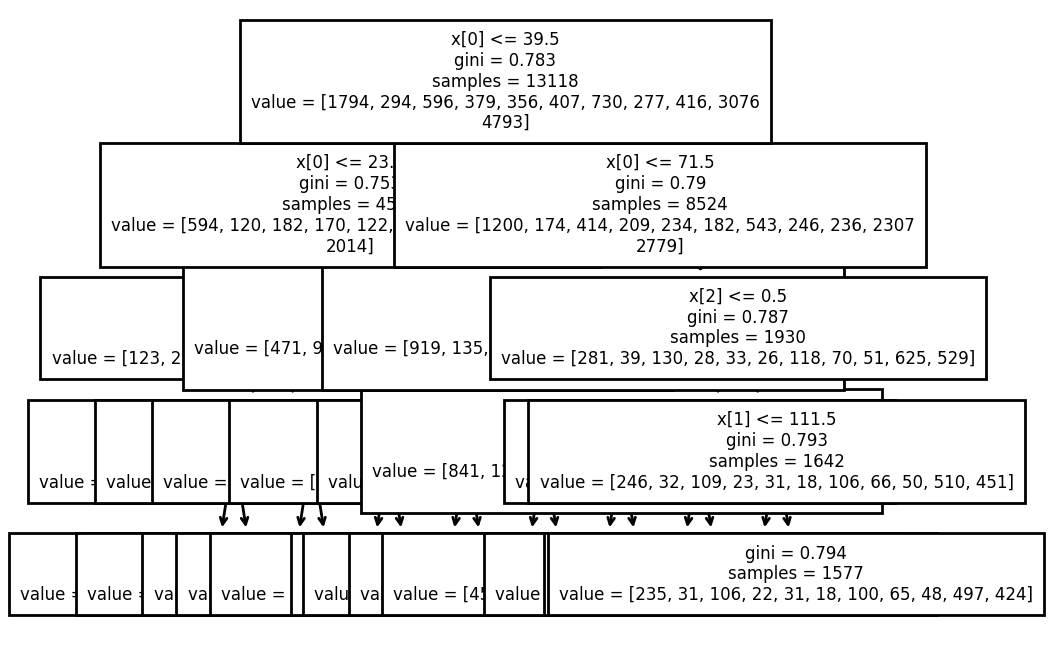

In [9]:
plt.figure(figsize=[4,4],dpi=200)
tree.plot_tree(clf, fontsize=6)
plt.show()

In [10]:
empstat_labels=({
        1:'Cheerios',
        2:'Cheerios, Honey Nut',
        3:'Corn flakes',
        4:'Frosted Flakes',
        5:'Granola',
        6:'Honey Bunches of Oat Honey Roasted',
        7:'Raisin Bran',
        8:'Shredded Wheat',
        9:'Special K',
        10:'Oatmeal',
        11:'Other'
    })

In [12]:
import graphviz
graph_data = tree.export_graphviz(clf, 
                                  feature_names=X_train.columns, 
                                  class_names=empstat_labels, 
                                  out_file=None, # Store the converted data in an object
                                  filled=True, # Color the nodes
                                  rounded=True, # Give the nodes a rounded look
                                  leaves_parallel=True) # Put the leaves together on the last␣
graph = graphviz.Source(graph_data)

## 5 Generate tree predictions

For the testing dataset, generate predictions for which cereal the decision tree thinks people would pick based on their features.

In [ ]:
y_predictions=pd.DataFrame(clf.predict(X_test)).rename(columns={0: "prediction"})

In [ ]:
y_predictions

,prediction
0,11.0
1,11.0
2,11.0
3,11.0
4,11.0
...,...
5617,10.0
5618,11.0
5619,11.0
5620,10.0


## 6 Check the fit of the tree 

I used the predicted I created previously to calculate the accuracy score for my tree using the testing dataset. 

In [ ]:
y_check=y_test.reset_index().drop('index', axis=1)
y_check

,cereal_num
0,6.0
1,8.0
2,10.0
3,10.0
4,11.0
...,...
5617,10.0
5618,11.0
5619,11.0
5620,11.0


In [ ]:
y_compare=(pd.concat([y_check,y_predictions], axis=1))
y_compare['correct_prediction']=(y_compare['prediction']==y_compare['cereal_num'])

In [ ]:
y_compare['correct_prediction'].value_counts()

correct_prediction
False    3532
True     2090
Name: count, dtype: int64

In [ ]:
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_compare['prediction'],y_compare['cereal_num']))

Accuracy: 0.3717538242618285


The tree makes the correct prediction about 37% of the time

## 7 Random Forest

Let's build another classifier, this time using a random forest. Define your random forest classifier by 
filling in the blanks below.

In [ ]:
# Define a decision tree classifier
# Instead of setting up a pruning process, we're going to take the
# quicker but cruder route and limit the number of splits 
# using max_leaf_nodes (e.g. max_leaf_nodes=8) so the tree
# doesn't grow indefinitely

from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(random_state=0,           # Define a consistent (psuedo-)random state
                            max_features=8,     # Number of features to consider while looking for split
                            n_estimators=1_000,          # Number of weak-learner trees
                            max_leaf_nodes=30,             # Number of nodes allowed in each tree
                            max_depth=6               # Amount of branching allowed in each tree
                          )

Now, use the same training datasets I used for the decision tree to train my forest.

In [ ]:
rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, max_features=8, max_leaf_nodes=30,
                       n_estimators=1000, random_state=0)

## 8 Create random forest predictions

I used the random forest model to generate predicted cereal choices for the testing dataset. 

In [ ]:
y_compare['rf_prediction']=rfc.predict(X_test)

In [ ]:
y_compare['correct_rf_prediction']=(y_compare['rf_prediction']==y_compare['cereal_num'])

In [ ]:
y_compare

,cereal_num,prediction,correct_prediction,rf_prediction,correct_rf_prediction
0,6.0,11.0,False,11.0,False
1,8.0,11.0,False,11.0,False
2,10.0,11.0,False,11.0,False
3,10.0,11.0,False,11.0,False
4,11.0,11.0,True,11.0,True
...,...,...,...,...,...
5617,10.0,10.0,True,10.0,True
5618,11.0,11.0,True,11.0,True
5619,11.0,11.0,True,11.0,True
5620,11.0,10.0,False,10.0,False


## Q Calculate the accuracy of the random forest model

I used `.accuracy_score()` to calculate the fraction of the time the random forest model correctly predicted cereal choice in the testing subsample.

In [ ]:
print("Forest Accuracy:",metrics.accuracy_score(y_compare['rf_prediction'],y_compare['cereal_num']))

Forest Accuracy: 0.3783351120597652


The random forest makes the correct prediction about 37.7% of the time. This is about 0.6 percentage points higher than the tree, which made the correct prediction about 37.1% of the time. 